# 03 Model US - Two-stage Transfer Model

This notebook implements a two-stage DeepSolar-style modeling workflow.

- Stage 1: binary classification, `tile_count > 0`, whether solar deployment exists.
- Stage 2: regression, only on installed tracts, how much deployment exists.

This is separate from `03_model_us.ipynb`, which is kept as the multiclass baseline.

In [1]:
import sys
sys.path.append('../')

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix

from src.model import TWOSTAGE_MODELS, cross_validate_twostage, evaluate_binary_classifier, evaluate_regressor, set_seed

set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
PROFILE = 'transfer'
FEATURE_SET = 'voted'   # voted(90) | tree(102) | vif(55)
MODEL_FAMILY = 'RandomForest'  # 詳細分析（混淆矩陣、特徵重要性）使用的模型
# 可選：RandomForest | XGBoost | GradientBoosting | Linear

DATA_PATH = '../deepsolar_tract.csv'
FEATURE_PATH = f'../outputs/results/{PROFILE}/selected_features_{FEATURE_SET}.csv'
RESULT_DIR = Path(f'../outputs/results/{PROFILE}')
FIGURE_DIR = Path(f'../outputs/figures/{PROFILE}')
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Profile:', PROFILE)
print('Feature set:', FEATURE_SET)
print('Primary model for detailed analysis:', MODEL_FAMILY)
print('All comparison models:', list(TWOSTAGE_MODELS.keys()))

Profile: transfer
Feature set: voted
Primary model for detailed analysis: RandomForest
All comparison models: ['RandomForest', 'XGBoost', 'GradientBoosting', 'Linear']


In [3]:
raw_df = pd.read_csv(DATA_PATH, encoding='latin-1')
selected = pd.read_csv(FEATURE_PATH)
feature_names = selected['feature'].tolist()

missing_features = [c for c in feature_names if c not in raw_df.columns]
if missing_features:
    raise ValueError(f'Missing selected features in raw data: {missing_features}')

model_df = raw_df[feature_names + ['tile_count', 'household_count']].copy()
model_df = model_df.dropna(subset=['tile_count'])

X_raw = model_df[feature_names].values
y_tile = model_df['tile_count'].astype(float).values

# household_count NaN: fill with column median (not 1) to avoid inflating density
household_nan_count = model_df['household_count'].isna().sum()
household_median = model_df['household_count'].median()
y_households = model_df['household_count'].fillna(household_median).clip(lower=1).values
y_density = y_tile / y_households * 1000  # solar systems per thousand households
y_installed = (y_tile > 0).astype(int)

print('Rows:', len(model_df))
print('Features:', len(feature_names))
print(f'household_count NaN: {household_nan_count} ({household_nan_count/len(model_df)*100:.1f}%) → 以中位數 {household_median:.0f} 補值')
print('Installed distribution:')
print(dict(zip(*np.unique(y_installed, return_counts=True))))
print('Installed rate:', y_installed.mean().round(4))
print('Density (per 1000 HH) among installed — mean:', y_density[y_installed == 1].mean().round(2),
      '  median:', np.median(y_density[y_installed == 1]).round(2))

Rows: 72537
Features: 90
household_count NaN: 0 (0.0%) → 以中位數 1517 補值
Installed distribution:
{np.int64(0): np.int64(16279), np.int64(1): np.int64(56258)}
Installed rate: 0.7756
Density (per 1000 HH) among installed — mean: 216.0   median: 5.31


In [4]:
X_train_raw, X_test_raw, y_inst_train, y_inst_test, y_tile_train, y_tile_test, y_dens_train, y_dens_test = train_test_split(
    X_raw,
    y_installed,
    y_tile,
    y_density,
    test_size=0.2,
    random_state=42,
    stratify=y_installed,
)

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train_raw)
X_test = imputer.transform(X_test_raw)

print('Train rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Train installed rate:', y_inst_train.mean().round(4))
print('Test installed rate:', y_inst_test.mean().round(4))

Train rows: 58029
Test rows: 14508
Train installed rate: 0.7756
Test installed rate: 0.7756


## Comprehensive Comparison（Feature Set × Model Family）

對 **3 個特徵集 × 4 個模型家族 = 12 組組合**，每組都跑：
- 10-fold full-pipeline CV（端對端 R² + Stage 1 F1）
- Hold-out Stage 1 分類指標（ROC-AUC / F1 / Precision / Recall）
- Hold-out Stage 2 迴歸指標（log1p R² / density R² / MAE / RMSE）

| 特徵集 | 數量 | 設計目的 |
|--------|------|---------|
| `voted` | 90 | Lasso + ElasticNet + RF 投票，Ch9 最嚴謹 |
| `tree` | 102 | 相關篩選，對應論文 SolarForest |
| `vif` | 55 | VIF < 10，MultiCollinearity 最低，適合 Linear |

結果存入 `twostage_full_comparison.csv`，可輸出 pivot table 快速比較。

後面的 Stage 1 / Stage 2 詳細分析（confusion matrix、特徵重要性）使用 config cell 指定的 `MODEL_FAMILY` + `FEATURE_SET`。

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FEATURE_SETS = ['voted', 'tree', 'vif']
full_results = []

for fs in FEATURE_SETS:
    fs_path = RESULT_DIR / f'selected_features_{fs}.csv'
    fs_features = pd.read_csv(fs_path)['feature'].tolist()

    # 每個特徵集重新取 X（y 只跟 tile_count/household_count 有關，不受特徵集影響）
    fs_df = raw_df[fs_features + ['tile_count', 'household_count']].copy()
    fs_df = fs_df.dropna(subset=['tile_count'])
    X_raw_fs = fs_df[fs_features].values

    y_tile_fs   = fs_df['tile_count'].astype(float).values
    hh_med      = fs_df['household_count'].median()
    y_hh_fs     = fs_df['household_count'].fillna(hh_med).clip(lower=1).values
    y_dens_fs   = y_tile_fs / y_hh_fs * 1000
    y_inst_fs   = (y_tile_fs > 0).astype(int)

    (X_tr_raw, X_te_raw,
     y_itr, y_ite,
     y_dtr, y_dte) = train_test_split(
        X_raw_fs, y_inst_fs, y_dens_fs,
        test_size=0.2, random_state=42, stratify=y_inst_fs,
    )
    imp_fs  = SimpleImputer(strategy='median')
    X_tr_fs = imp_fs.fit_transform(X_tr_raw)
    X_te_fs = imp_fs.transform(X_te_raw)

    print(f'\n=== Feature set: {fs} ({len(fs_features)} features) ===')

    for family_name, family_models in TWOSTAGE_MODELS.items():
        print(f'  {family_name} CV ...', end=' ', flush=True)

        cv_res = cross_validate_twostage(
            family_models['classifier'], family_models['regressor'],
            X_raw_fs, y_inst_fs, y_dens_fs, cv=10,
        )

        clf_fitted, clf_m = evaluate_binary_classifier(
            family_models['classifier'], X_tr_fs, X_te_fs, y_itr, y_ite
        )

        tr_pos, te_pos = y_itr == 1, y_ite == 1
        reg_fitted, reg_m_log = evaluate_regressor(
            family_models['regressor'],
            X_tr_fs[tr_pos], X_te_fs[te_pos],
            np.log1p(y_dtr[tr_pos]), np.log1p(y_dte[te_pos]),
        )
        raw_pred = np.clip(np.expm1(reg_fitted.predict(X_te_fs[te_pos])), 0, None)
        reg_m_raw = {
            'mae_density':  mean_absolute_error(y_dte[te_pos], raw_pred),
            'rmse_density': mean_squared_error(y_dte[te_pos], raw_pred) ** 0.5,
            'r2_density':   r2_score(y_dte[te_pos], raw_pred),
        }

        full_results.append({
            'feature_set':  fs,
            'n_features':   len(fs_features),
            'model_family': family_name,
            **{f'cv_{k}': v for k, v in cv_res.items()},
            **{f'stage1_{k}': v for k, v in clf_m.items()},
            **{f'stage2_{k}_log1p': v for k, v in reg_m_log.items()},
            **reg_m_raw,
        })
        print(f"cv_R²={cv_res['cv_r2_mean']:.3f}±{cv_res['cv_r2_std']:.3f}  "
              f"F1={cv_res['cv_stage1_f1_mean']:.3f}")

full_df = pd.DataFrame(full_results)
full_path = RESULT_DIR / 'twostage_full_comparison.csv'
full_df.to_csv(full_path, index=False)

print('\n=== CV R² Pivot (feature_set × model_family) ===')
print(full_df.pivot_table(
    index='model_family', columns='feature_set', values='cv_r2_mean'
).round(4).to_string())

print('\n=== Stage 1 ROC-AUC Pivot ===')
print(full_df.pivot_table(
    index='model_family', columns='feature_set', values='stage1_roc_auc'
).round(4).to_string())

print(f'\nFull results saved to {full_path}')


=== Feature set: voted (90 features) ===
  RandomForest CV ... cv_R²=0.089±0.074  F1=0.896
  XGBoost CV ... cv_R²=0.029±0.261  F1=0.899
  GradientBoosting CV ... cv_R²=0.109±0.105  F1=0.899
  Linear CV ... cv_R²=0.001±0.002  F1=0.828

=== Feature set: tree (102 features) ===
  RandomForest CV ... cv_R²=0.090±0.085  F1=0.895
  XGBoost CV ... cv_R²=0.066±0.113  F1=0.899
  GradientBoosting CV ... cv_R²=0.089±0.144  F1=0.900
  Linear CV ... cv_R²=0.017±0.017  F1=0.829

=== Feature set: vif (55 features) ===
  RandomForest CV ... cv_R²=0.087±0.106  F1=0.895
  XGBoost CV ... cv_R²=-0.793±2.523  F1=0.898
  GradientBoosting CV ... cv_R²=0.038±0.247  F1=0.899
  Linear CV ... cv_R²=-0.000±0.001  F1=0.822

=== CV R² Pivot (feature_set × model_family) ===


KeyError: 'cv_r2_mean'

In [7]:
# 修正雙重 cv_ 前綴，並重新存檔
rename_map = {c: c[3:] for c in full_df.columns if c.startswith('cv_cv_')}
full_df = full_df.rename(columns=rename_map)
full_df.to_csv(full_path, index=False)

def show_pivot(col, title):
    print(f'\n=== {title} ===')
    print(full_df.pivot_table(
        index='model_family', columns='feature_set', values=col
    ).round(4).to_string())

# ── CV ──────────────────────────────────────────
show_pivot('cv_r2_mean',          'CV R² mean (end-to-end, all tracts)')
show_pivot('cv_r2_std',           'CV R² std')
show_pivot('cv_stage1_f1_mean',   'CV Stage1 F1 mean')
show_pivot('cv_stage1_f1_std',    'CV Stage1 F1 std')

# ── Stage 1 Hold-out ────────────────────────────
show_pivot('stage1_roc_auc',  'Stage1 ROC-AUC (hold-out)')
show_pivot('stage1_f1',       'Stage1 F1 (hold-out)')
show_pivot('stage1_precision','Stage1 Precision (hold-out)')
show_pivot('stage1_recall',   'Stage1 Recall (hold-out)')
show_pivot('stage1_accuracy', 'Stage1 Accuracy (hold-out)')

# ── Stage 2 Hold-out ────────────────────────────
show_pivot('stage2_r2_log1p',   'Stage2 R² log1p scale (installed only)')
show_pivot('stage2_mae_log1p',  'Stage2 MAE log1p scale')
show_pivot('stage2_rmse_log1p', 'Stage2 RMSE log1p scale')
show_pivot('r2_density',        'Stage2 R² density scale (installed only)')
show_pivot('mae_density',       'Stage2 MAE density scale')
show_pivot('rmse_density',      'Stage2 RMSE density scale')

print(f'\nFull results saved to {full_path}')


=== CV R² mean (end-to-end, all tracts) ===
feature_set         tree     vif   voted
model_family                            
GradientBoosting  0.0895  0.0381  0.1088
Linear            0.0172 -0.0003  0.0012
RandomForest      0.0902  0.0873  0.0886
XGBoost           0.0656 -0.7935  0.0287

=== CV R² std ===
feature_set         tree     vif   voted
model_family                            
GradientBoosting  0.1437  0.2475  0.1054
Linear            0.0166  0.0006  0.0016
RandomForest      0.0848  0.1064  0.0740
XGBoost           0.1130  2.5230  0.2610

=== CV Stage1 F1 mean ===
feature_set         tree     vif   voted
model_family                            
GradientBoosting  0.8995  0.8986  0.8991
Linear            0.8291  0.8220  0.8284
RandomForest      0.8954  0.8951  0.8956
XGBoost           0.8989  0.8980  0.8992

=== CV Stage1 F1 std ===
feature_set         tree     vif   voted
model_family                            
GradientBoosting  0.0018  0.0019  0.0017
Linear            0.00

## 超參數調整（Appendix D）

對 `MODEL_FAMILY` 的 Stage 1 與 Stage 2 分別執行 `RandomizedSearchCV`，依各自目標獨立調整（sequential tuning）。

| 階段 | 目標 | Scoring | CV |
|------|------|---------|-----|
| Stage 1 | Classifier | F1 | StratifiedKFold（保持類別比例） |
| Stage 2 | Regressor（僅正類） | R²（log1p 尺度） | KFold |

> Linear 不在此調整（Pipeline 參數名需加前綴 `clf__` / `reg__`）。  
> 調整後的模型存入 `best_us_twostage_model_{FEATURE_SET}_tuned.pkl`，供台灣遷移推論使用。

In [8]:
from src.model import tune_twostage, TWOSTAGE_PARAM_GRIDS

if MODEL_FAMILY not in TWOSTAGE_PARAM_GRIDS:
    print(f'{MODEL_FAMILY} 不在 TWOSTAGE_PARAM_GRIDS（僅支援 RandomForest / XGBoost / GradientBoosting）。')
    print('跳過超參數調整。')
    tuned_clf = TWOSTAGE_MODELS[MODEL_FAMILY]['classifier']
    tuned_reg = TWOSTAGE_MODELS[MODEL_FAMILY]['regressor']
    tune_metrics = None
else:
    print(f'=== Tuning {MODEL_FAMILY}: n_iter=20, 5-fold CV ===')
    tuned_clf, tuned_reg, tune_metrics = tune_twostage(
        MODEL_FAMILY, X_raw, y_installed, y_density, n_iter=20, cv=5
    )
    tuned_bundle = {
        'profile': PROFILE,
        'feature_set': FEATURE_SET,
        'model_family': MODEL_FAMILY,
        'feature_names': feature_names,
        'imputer': imputer,
        'classifier': tuned_clf,
        'regressor': tuned_reg,
        'stage1_target': 'tile_count > 0',
        'stage2_target': 'log1p(tile_count / household_count * 1000), trained only where tile_count > 0',
        'tune_metrics': tune_metrics,
    }
    tuned_path = RESULT_DIR / f'best_us_twostage_model_{FEATURE_SET}_tuned.pkl'
    with open(tuned_path, 'wb') as f:
        pickle.dump(tuned_bundle, f)
    print(f'\nTuned bundle 已存至 {tuned_path}')
    print(f"Stage 1 best F1       : {tune_metrics['stage1_best_f1']:.4f}")
    print(f"Stage 2 best R² log1p : {tune_metrics['stage2_best_r2_log1p']:.4f}")

=== Tuning RandomForest: n_iter=20, 5-fold CV ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Stage 1 best F1 : 0.8968
Stage 1 best params: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Stage 2 best R² (log1p): 0.7510
Stage 2 best params: {'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 0.3, 'max_depth': None}

Tuned bundle 已存至 ..\outputs\results\transfer\best_us_twostage_model_voted_tuned.pkl
Stage 1 best F1       : 0.8968
Stage 2 best R² log1p : 0.7510


## Stage 1 - Binary Deployment Classifier

The first stage predicts whether a tract has any observed solar deployment.

Target:

```text
tile_count > 0 -> 1
tile_count = 0 -> 0
```

In [9]:
models = TWOSTAGE_MODELS[MODEL_FAMILY]
classifier, clf_metrics = evaluate_binary_classifier(
    models['classifier'], X_train, X_test, y_inst_train, y_inst_test
)

if hasattr(classifier, 'oob_score_'):
    print(f'Stage 1 OOB Accuracy: {classifier.oob_score_:.4f}')

clf_df = pd.DataFrame([{'model_family': MODEL_FAMILY, **clf_metrics}])
clf_path = RESULT_DIR / f'twostage_classifier_metrics_{FEATURE_SET}.csv'
clf_df.to_csv(clf_path, index=False)

print(clf_df.to_string(index=False))
print(f'Saved to {clf_path}')

Stage 1 OOB Accuracy: 0.8271
model_family  accuracy       f1  precision   recall  roc_auc
RandomForest  0.824648 0.893663   0.843592 0.950053 0.863742
Saved to ..\outputs\results\transfer\twostage_classifier_metrics_voted.csv


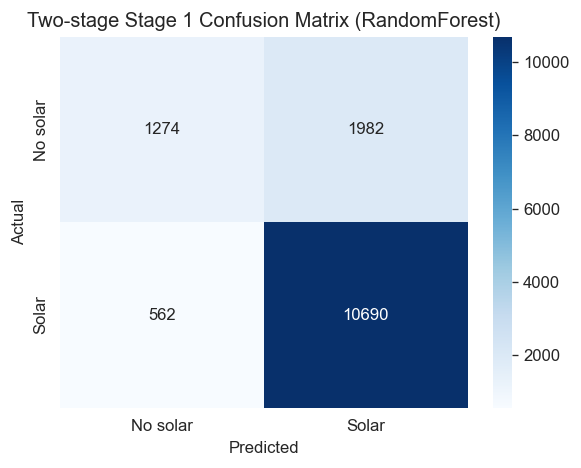

Saved to ..\outputs\figures\transfer\03_twostage_stage1_confusion_matrix_voted.png


In [10]:
y_inst_pred = classifier.predict(X_test)
cm = confusion_matrix(y_inst_test, y_inst_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No solar', 'Solar'], yticklabels=['No solar', 'Solar'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Two-stage Stage 1 Confusion Matrix ({MODEL_FAMILY})')
plt.tight_layout()
fig_path = FIGURE_DIR / f'03_twostage_stage1_confusion_matrix_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

## Stage 2 - Deployment Density Regressor

The second stage trains only on tracts where solar deployment exists. The regression target is `log1p(tile_count / household_count * 1000)` — solar systems per thousand households — matching the DeepSolar paper's SolarForest density metric.

Using density instead of raw `tile_count` removes the confounding effect of tract population size, making the metric suitable for cross-regional comparison and Taiwan transfer.

Both log-scale metrics and original density-scale metrics are reported.

In [11]:
train_positive = y_inst_train == 1
test_positive = y_inst_test == 1

X_reg_train = X_train[train_positive]
X_reg_test = X_test[test_positive]
y_reg_train_log = np.log1p(y_dens_train[train_positive])
y_reg_test_log = np.log1p(y_dens_test[test_positive])
y_reg_test_raw = y_dens_test[test_positive]

regressor, reg_metrics_log = evaluate_regressor(
    models['regressor'], X_reg_train, X_reg_test, y_reg_train_log, y_reg_test_log
)

if hasattr(regressor, 'oob_score_'):
    print(f'Stage 2 OOB R² (log1p scale): {regressor.oob_score_:.4f}')

log_pred = regressor.predict(X_reg_test)
raw_pred = np.expm1(log_pred)
raw_pred = np.clip(raw_pred, 0, None)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
reg_metrics_raw = {
    'mae_density': mean_absolute_error(y_reg_test_raw, raw_pred),
    'rmse_density': mean_squared_error(y_reg_test_raw, raw_pred) ** 0.5,
    'r2_density': r2_score(y_reg_test_raw, raw_pred),
}

reg_df = pd.DataFrame([{
    'model_family': MODEL_FAMILY,
    'train_positive_rows': int(train_positive.sum()),
    'test_positive_rows': int(test_positive.sum()),
    **{f'{k}_log1p': v for k, v in reg_metrics_log.items()},
    **reg_metrics_raw,
}])
reg_path = RESULT_DIR / f'twostage_regressor_metrics_{FEATURE_SET}.csv'
reg_df.to_csv(reg_path, index=False)

print(reg_df.to_string(index=False))
print(f'Saved to {reg_path}')

Stage 2 OOB R² (log1p scale): 0.7428
model_family  train_positive_rows  test_positive_rows  mae_log1p  rmse_log1p  r2_log1p  mae_density  rmse_density  r2_density
RandomForest                45006               11252   0.547256    0.730652  0.750096   257.783405   9495.922753    0.085184
Saved to ..\outputs\results\transfer\twostage_regressor_metrics_voted.csv


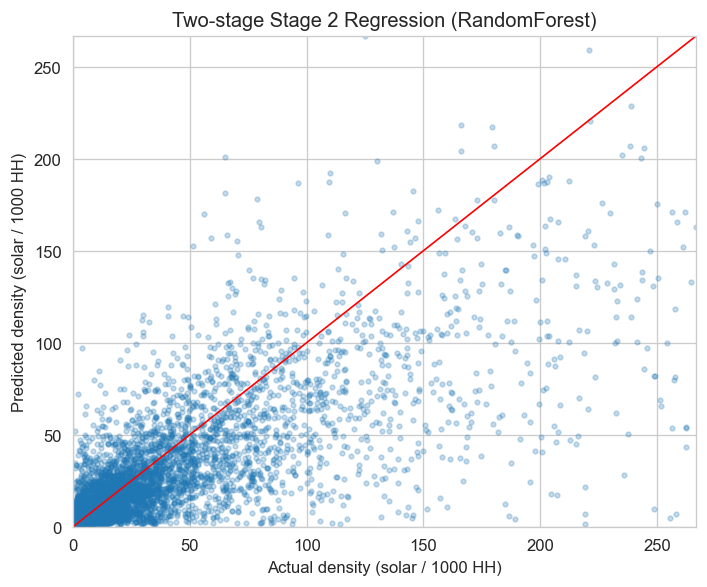

Saved to ..\outputs\figures\transfer\03_twostage_stage2_predicted_vs_actual_voted.png


In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(y_reg_test_raw, raw_pred, s=8, alpha=0.25)
limit = np.percentile(np.concatenate([y_reg_test_raw, raw_pred]), 99)
plt.plot([0, limit], [0, limit], color='red', linewidth=1)
plt.xlim(0, limit)
plt.ylim(0, limit)
plt.xlabel('Actual density (solar / 1000 HH)')
plt.ylabel('Predicted density (solar / 1000 HH)')
plt.title(f'Two-stage Stage 2 Regression ({MODEL_FAMILY})')
plt.tight_layout()
fig_path = FIGURE_DIR / f'03_twostage_stage2_predicted_vs_actual_{FEATURE_SET}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {fig_path}')

## Feature Importance

Feature importance is reported separately for the two stages because the two stages answer different questions.

- Stage 1 importance: which features help distinguish no deployment vs any deployment.
- Stage 2 importance: among deployed tracts, which features help explain deployment intensity.

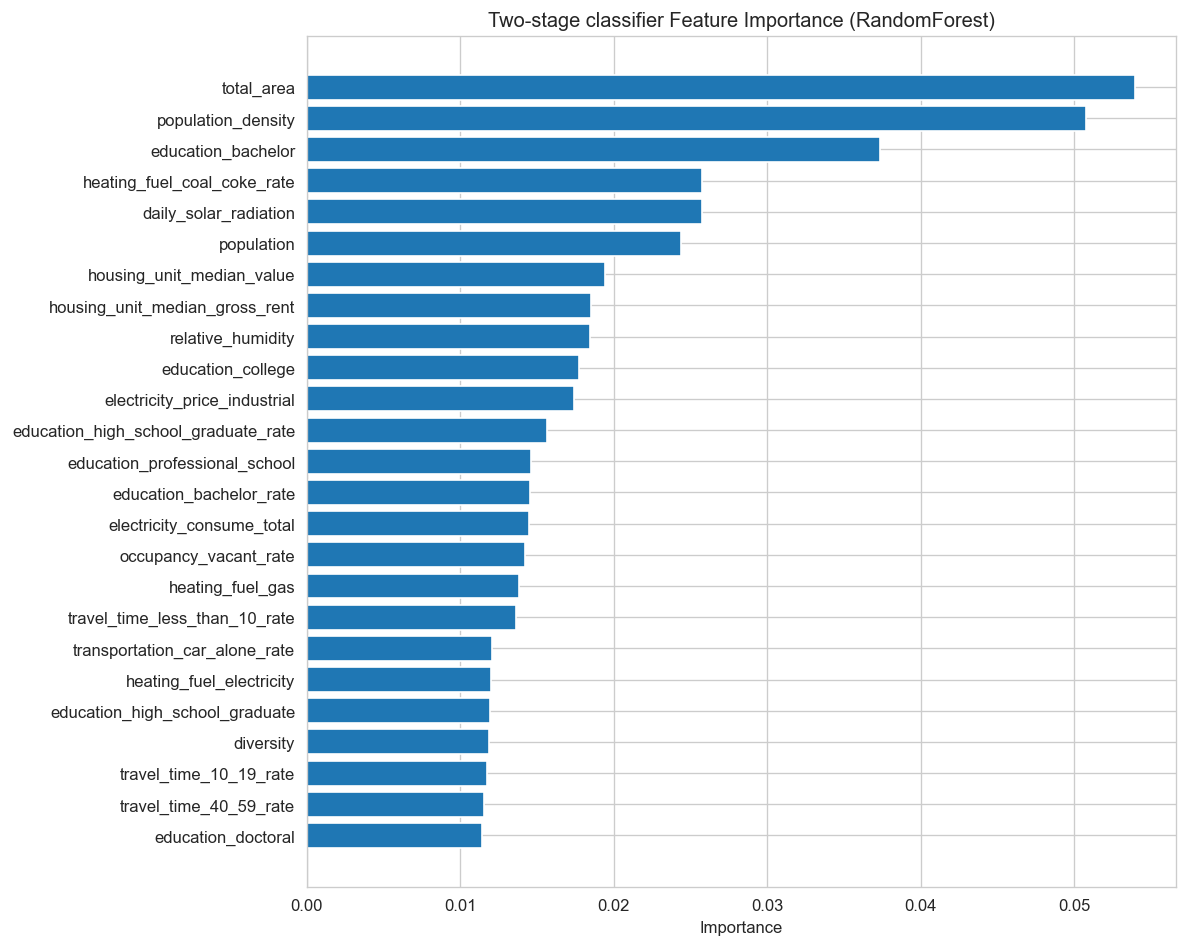

Saved to ..\outputs\results\transfer\twostage_feature_importance_classifier_voted.csv
Saved to ..\outputs\figures\transfer\03_twostage_feature_importance_classifier_voted.png


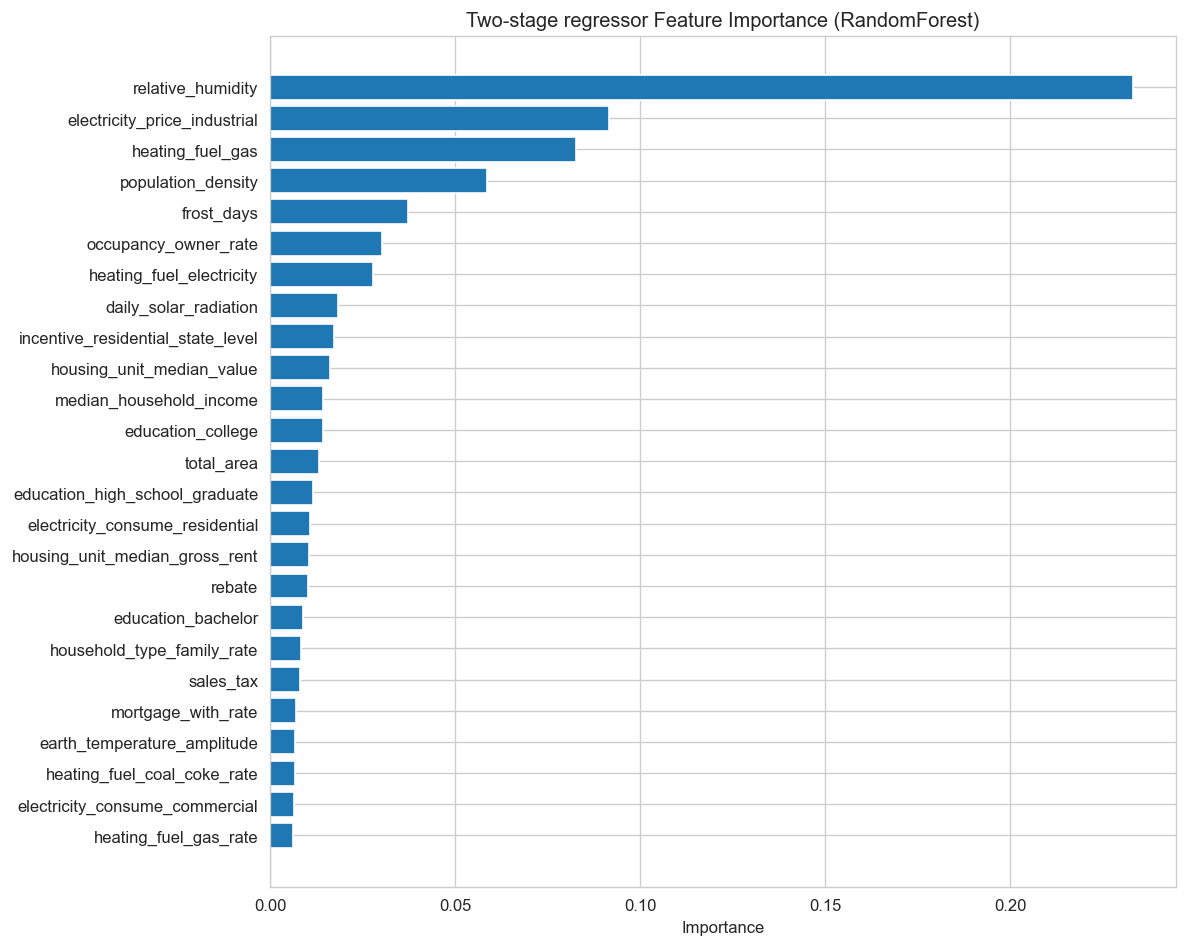

Saved to ..\outputs\results\transfer\twostage_feature_importance_regressor_voted.csv
Saved to ..\outputs\figures\transfer\03_twostage_feature_importance_regressor_voted.png


In [13]:
def save_feature_importance(model, stage_name):
    if not hasattr(model, 'feature_importances_'):
        print(f'{stage_name} model does not expose feature_importances_.')
        return None
    imp = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
    out_path = RESULT_DIR / f'twostage_feature_importance_{stage_name}_{FEATURE_SET}.csv'
    imp.to_csv(out_path, index=False)

    plt.figure(figsize=(10, 8))
    top = imp.head(25).sort_values('importance')
    plt.barh(top['feature'], top['importance'])
    plt.xlabel('Importance')
    plt.title(f'Two-stage {stage_name} Feature Importance ({MODEL_FAMILY})')
    plt.tight_layout()
    fig_path = FIGURE_DIR / f'03_twostage_feature_importance_{stage_name}_{FEATURE_SET}.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Saved to {out_path}')
    print(f'Saved to {fig_path}')
    return imp

clf_imp = save_feature_importance(classifier, 'classifier')
reg_imp = save_feature_importance(regressor, 'regressor')

In [14]:
bundle = {
    'profile': PROFILE,
    'feature_set': FEATURE_SET,
    'model_family': MODEL_FAMILY,
    'feature_names': feature_names,
    'imputer': imputer,
    'classifier': classifier,
    'regressor': regressor,
    'stage1_target': 'tile_count > 0',
    'stage2_target': 'log1p(tile_count / household_count * 1000), trained only where tile_count > 0',
    'classifier_metrics': clf_metrics,
    'regressor_metrics_log1p': reg_metrics_log,
    'regressor_metrics_raw': reg_metrics_raw,
}

model_path = RESULT_DIR / f'best_us_twostage_model_{FEATURE_SET}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(bundle, f)

print(f'Saved to {model_path}')

Saved to ..\outputs\results\transfer\best_us_twostage_model_voted.pkl


## Interpretation Note

This two-stage model is conceptually different from the multiclass baseline.

The multiclass baseline predicts deployment level classes made from quantiles of `tile_count`.

The two-stage model separates the problem into:

1. Whether deployment exists.
2. How much deployment exists, conditional on deployment existing.

This is closer to the DeepSolar SolarForest modeling idea and should be treated as the more formal US baseline for later Taiwan transfer work.